In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Flood Events in Malaysia (2000–2010)

## Problem Scoping

Flooding is a recurring environmental issue in Malaysia, particularly during
monsoon seasons. This notebook explores historical flood records from 2000 to
2010 to identify basic temporal patterns and affected regions.

The aim is to gain an initial understanding of flood trends using simple
exploratory data analysis and visualisation.

# Notes
Problem Scoping - Data - EDA - Visualisation - Data Story

In [1]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/flood-events-in-malaysia-20002010/rekod-banjir-2000-hingga-2010.xls


In [8]:
import pandas as pd

df = pd.read_excel(file_path)
df.head()


/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,Unnamed: 0,APPENDIX B :,"LIST OF RBMU AND RIVER SYSTEM IN PENINSULAR MALAYSIA, SABAH AND SARAWAK",Unnamed: 3
0,NaN,NaN,NaN,NaN
1,NaN,State Code,RBMU Name,RBMU No.
2,NaN,1,PERLIS,NaN
3,NaN,NaN,Sungai Perlis,1
4,NaN,NaN,NaN,NaN


In [9]:
import pandas as pd

file_path = "/kaggle/input/flood-events-in-malaysia-20002010/rekod-banjir-2000-hingga-2010.xls"

xls = pd.ExcelFile(file_path)
xls.sheet_names


['RBMU_LIST', '1 MALAYSIA']

In [10]:
import pandas as pd

file_path = "/kaggle/input/flood-events-in-malaysia-20002010/rekod-banjir-2000-hingga-2010.xls"

df_raw = pd.read_excel(file_path, sheet_name="1 MALAYSIA", header=None)
df_raw.head(15)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,SUMMARY OF FLOOD EVENT (2000 - 2010) BY RBMU F...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,RBMU No.,Item,2002\nStudy (KTA),2012 Study (DNA),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Negeri
2,NaN,NaN,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,TOTAL,NaN
3,1\nLembangan Sg. Perlis,No. of Flood Event,1,NaN,NaN,NaN,NaN,1,1,NaN,NaN,2,1,5,Perlis
4,NaN,River & Date of Flood,NaN,NaN,NaN,NaN,NaN,Sg. Perlis\n17-25/12,Sg. Buluh\n21-22/10,NaN,NaN,Sg. Jarum\n11/6,Sg. Pelarit\n1-8/11,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Sg. Arau\n17-24/12,Sg. Alor Mentalun\n21-22/10,NaN,NaN,Sg. Pelarit \n11/6,Sg. Jarum\n1-8/11,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Sg. Arau\n21-22/10,NaN,NaN,Sg. Buluh\n11/6,Sg. Buluh\n1-8/11,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Sg. Mentalun\n29/3,Sg. Panggas\n1-8/11,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Sg. Jerneh\n1-8/11,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Sg. Arau\n1-8/11,NaN,NaN


Notes - Dataset is not tidy/messy :(
Data is cross-tab summary table
Actual flood data - Row 3 onwards

In [12]:
df = pd.read_excel(
    file_path,
    sheet_name="1 MALAYSIA",
    skiprows=2
)

df.head()


/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,Unnamed: 0,Unnamed: 1,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,TOTAL,Unnamed: 14
0,1\nLembangan Sg. Perlis,No. of Flood Event,1,NaN,NaN,NaN,NaN,1,1,NaN,NaN,2,1,5.0,Perlis
1,NaN,River & Date of Flood,NaN,NaN,NaN,NaN,NaN,Sg. Perlis\n17-25/12,Sg. Buluh\n21-22/10,NaN,NaN,Sg. Jarum\n11/6,Sg. Pelarit\n1-8/11,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Sg. Arau\n17-24/12,Sg. Alor Mentalun\n21-22/10,NaN,NaN,Sg. Pelarit \n11/6,Sg. Jarum\n1-8/11,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Sg. Arau\n21-22/10,NaN,NaN,Sg. Buluh\n11/6,Sg. Buluh\n1-8/11,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Sg. Mentalun\n29/3,Sg. Panggas\n1-8/11,NaN,NaN


In [13]:
df = df.dropna(how="all")
df = df.reset_index(drop=True)

df.head()


/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,Unnamed: 0,Unnamed: 1,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,TOTAL,Unnamed: 14
0,1\nLembangan Sg. Perlis,No. of Flood Event,1,NaN,NaN,NaN,NaN,1,1,NaN,NaN,2,1,5.0,Perlis
1,NaN,River & Date of Flood,NaN,NaN,NaN,NaN,NaN,Sg. Perlis\n17-25/12,Sg. Buluh\n21-22/10,NaN,NaN,Sg. Jarum\n11/6,Sg. Pelarit\n1-8/11,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Sg. Arau\n17-24/12,Sg. Alor Mentalun\n21-22/10,NaN,NaN,Sg. Pelarit \n11/6,Sg. Jarum\n1-8/11,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Sg. Arau\n21-22/10,NaN,NaN,Sg. Buluh\n11/6,Sg. Buluh\n1-8/11,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Sg. Mentalun\n29/3,Sg. Panggas\n1-8/11,NaN,NaN


In [14]:
df = df.rename(columns={df.columns[0]: "location"})
df.head()


/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,location,Unnamed: 1,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,TOTAL,Unnamed: 14
0,1\nLembangan Sg. Perlis,No. of Flood Event,1,NaN,NaN,NaN,NaN,1,1,NaN,NaN,2,1,5.0,Perlis
1,NaN,River & Date of Flood,NaN,NaN,NaN,NaN,NaN,Sg. Perlis\n17-25/12,Sg. Buluh\n21-22/10,NaN,NaN,Sg. Jarum\n11/6,Sg. Pelarit\n1-8/11,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Sg. Arau\n17-24/12,Sg. Alor Mentalun\n21-22/10,NaN,NaN,Sg. Pelarit \n11/6,Sg. Jarum\n1-8/11,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Sg. Arau\n21-22/10,NaN,NaN,Sg. Buluh\n11/6,Sg. Buluh\n1-8/11,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Sg. Mentalun\n29/3,Sg. Panggas\n1-8/11,NaN,NaN


### Observation on the data structure

The raw flood dataset is not tidy format. It contains:
- Multi-row headers
- Merged cells
- Year values spread across columns
- Mixed textual and numeric entries

Therefore, the dataset requires restructuring before meaningful analysis.


In [15]:
df.columns


Index([   'location',  'Unnamed: 1',          2000,          2001,
                2002,          2003,          2004,          2005,
                2006,          2007,          2008,          2009,
                2010,       'TOTAL', 'Unnamed: 14'],
      dtype='object')

In [16]:
df = df.drop(columns=["Unnamed: 1", "Unnamed: 14", "TOTAL"], errors="ignore")
df.head()


,location,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010
0,1\nLembangan Sg. Perlis,1,NaN,NaN,NaN,NaN,1,1,NaN,NaN,2,1
1,NaN,NaN,NaN,NaN,NaN,NaN,Sg. Perlis\n17-25/12,Sg. Buluh\n21-22/10,NaN,NaN,Sg. Jarum\n11/6,Sg. Pelarit\n1-8/11
2,NaN,NaN,NaN,NaN,NaN,NaN,Sg. Arau\n17-24/12,Sg. Alor Mentalun\n21-22/10,NaN,NaN,Sg. Pelarit \n11/6,Sg. Jarum\n1-8/11
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Sg. Arau\n21-22/10,NaN,NaN,Sg. Buluh\n11/6,Sg. Buluh\n1-8/11
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Sg. Mentalun\n29/3,Sg. Panggas\n1-8/11


In [17]:
df["location"].unique()


array(['1\nLembangan Sg. Perlis', nan, '2\nLembangan Sg. Kedah',
       '3\nLembangan Sg. Yan', '4\nLembangan Sg. Merbok',
       '5\nLembangan Sg. Muda', '\n190\nLembangan Sg. Langkawi',
       '6\nLembangan Sg. Perai', '7\nLembangan Sg. Juru',
       '8\nLembangan Sg. Jawi', '\n191\nLembangan Sg. Pinang',
       '9\nLembangan Sg. Kerian', '10\nLembangan Sg. Kurau',
       '11\nLembangan Sg. Sungai Sangga Besar / Sepetang',
       '12\nLembangan Sg. Larut', '13\nLembangan Sg. Temerloh',
       '14\nLembangan Sg. Jarum Mas', '15\nLembangan Sg. Beruas',
       '16\nLembangan Sg. Manjung', '17\nLembangan Sg. Tiram',
       '18\nLembangan Sg. Perak', '19\nLembangan Sg. Bernam',
       '20\nLembangan Sg. Tengi', '21\nLembangan Sg. Selangor',
       '22\nLembangan Sg. Buloh', '23\nLembangan Sg. Klang',
       '24\nLembangan Sg. Langat', '25\nLembangan Sg. Sepang',
       '26\nLembangan Sg. Lukut Besar', '27\nLembangan Sg. Linggi',
       '28\nLembangan Sg. Baru', '29\nLembangan Sg. Melaka',

In [18]:
df_counts = df[df["location"].str.contains("No. of Flood", na=False)]
df_counts


,location,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010


Challenge:  dataset is structured for reporting rather than analysis, with multi-level headers and mixed data types, requires careful manual cleaning and restructurin

In [19]:
df = pd.read_excel(file_path, sheet_name="1 MALAYSIA", skiprows=2)

# rename the first two columns so it's clearer
df = df.rename(columns={df.columns[0]: "location_raw", df.columns[1]: "item"})

# keep only the rows that contain the numeric flood counts
df_counts = df[df["item"].astype(str).str.contains("No. of Flood", case=False, na=False)].copy()

df_counts.head()


,location_raw,item,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,TOTAL,Unnamed: 14
0,1\nLembangan Sg. Perlis,No. of Flood Event,1,NaN,NaN,NaN,NaN,1,1,NaN,NaN,2,1,5.0,Perlis
15,2\nLembangan Sg. Kedah,No. of Flood Event,1,NaN,2,1,NaN,1,1,5,1,4,1,16.0,Kedah
28,3\nLembangan Sg. Yan,No. of Flood Event,NaN,NaN,0,2,NaN,0,0,1,3,2,0,8.0,NaN
34,4\nLembangan Sg. Merbok,No. of Flood Event,NaN,NaN,3,1,NaN,0,0,1,3,0,1,9.0,NaN
43,5\nLembangan Sg. Muda,No. of Flood Event,1,NaN,0,2,NaN,1,2,4,0,3,5,17.0,NaN


In [27]:
df_counts = df_counts.drop(columns=["TOTAL", "Unnamed: 14"], errors="ignore")
df_counts.head()


,location_raw,item,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,location
0,1\nLembangan Sg. Perlis,No. of Flood Event,1,NaN,NaN,NaN,NaN,1,1,NaN,NaN,2,1,1\nLembangan Sg. Perlis
15,2\nLembangan Sg. Kedah,No. of Flood Event,1,NaN,2,1,NaN,1,1,5,1,4,1,2\nLembangan Sg. Kedah
28,3\nLembangan Sg. Yan,No. of Flood Event,NaN,NaN,0,2,NaN,0,0,1,3,2,0,3\nLembangan Sg. Yan
34,4\nLembangan Sg. Merbok,No. of Flood Event,NaN,NaN,3,1,NaN,0,0,1,3,0,1,4\nLembangan Sg. Merbok
43,5\nLembangan Sg. Muda,No. of Flood Event,1,NaN,0,2,NaN,1,2,4,0,3,5,5\nLembangan Sg. Muda


In [28]:
df_counts["location"] = (
    df_counts["location_raw"]
    .astype(str)
    .str.replace(r"^\s*\d+\s*\n", "", regex=True)     # remove "1\n"
    .str.replace(r"^\s*Lembangan\s+", "", regex=True) # remove "Lembangan "
    .str.strip()
)

df_counts[["location_raw", "location"]].head()


,location_raw,location
0,1\nLembangan Sg. Perlis,Sg. Perlis
15,2\nLembangan Sg. Kedah,Sg. Kedah
28,3\nLembangan Sg. Yan,Sg. Yan
34,4\nLembangan Sg. Merbok,Sg. Merbok
43,5\nLembangan Sg. Muda,Sg. Muda


In [29]:
year_cols = [c for c in df_counts.columns if isinstance(c, int)]  # 2000..2010

df_counts[year_cols] = df_counts[year_cols].apply(pd.to_numeric, errors="coerce")

df_long = df_counts.melt(
    id_vars=["location"],
    value_vars=year_cols,
    var_name="year",
    value_name="flood_events"
).dropna(subset=["flood_events"])

df_long["year"] = df_long["year"].astype(int)
df_long.head()


,location,year,flood_events
0,Sg. Perlis,2000,1.0
1,Sg. Kedah,2000,1.0
4,Sg. Muda,2000,1.0
6,Sg. Perai,2000,1.0
9,Sg. Pinang,2000,1.0


#Check flood events

In [30]:
top10 = (
    df_long.groupby("location")["flood_events"].sum()
    .sort_values(ascending=False)
    .head(10)
)
top10


location
Sg. Klang       151.0
Sg. Perak       131.0
Sg. Langat       62.0
Sg. Kerian       40.0
Sg. Selangor     35.0
Sg. Buloh        32.0
Sg. Padas        28.0
Sg. Jawi         26.0
Sg. Perai        26.0
Sg. Pahang       23.0
Name: flood_events, dtype: float64

In [31]:
yearly = df_long.groupby("year")["flood_events"].sum()
yearly


year
2000     78.0
2001     88.0
2002     82.0
2003    111.0
2004     75.0
2005     50.0
2006    125.0
2007    141.0
2008    114.0
2009    162.0
2010    110.0
Name: flood_events, dtype: float64

In [32]:
df_counts[["location_raw","location"]].head(10)


,location_raw,location
0,1\nLembangan Sg. Perlis,Sg. Perlis
15,2\nLembangan Sg. Kedah,Sg. Kedah
28,3\nLembangan Sg. Yan,Sg. Yan
34,4\nLembangan Sg. Merbok,Sg. Merbok
43,5\nLembangan Sg. Muda,Sg. Muda
54,\n190\nLembangan Sg. Langkawi,Sg. Langkawi
63,6\nLembangan Sg. Perai,Sg. Perai
76,7\nLembangan Sg. Juru,Sg. Juru
86,8\nLembangan Sg. Jawi,Sg. Jawi
94,\n191\nLembangan Sg. Pinang,Sg. Pinang


3.0	Scope of the Study

This study focuses on:

1. Flood occurrence trends in Malaysia over the past 10 years
2. Identification of flood hotspot states
3. Seasonal patterns of flooding based on time of year


#Visualisation - line chart - shows temporal data and changes occurences over time

Figure 1.0 The line chart shows that flood occurences fluctuatues accross the 2000-2010 period

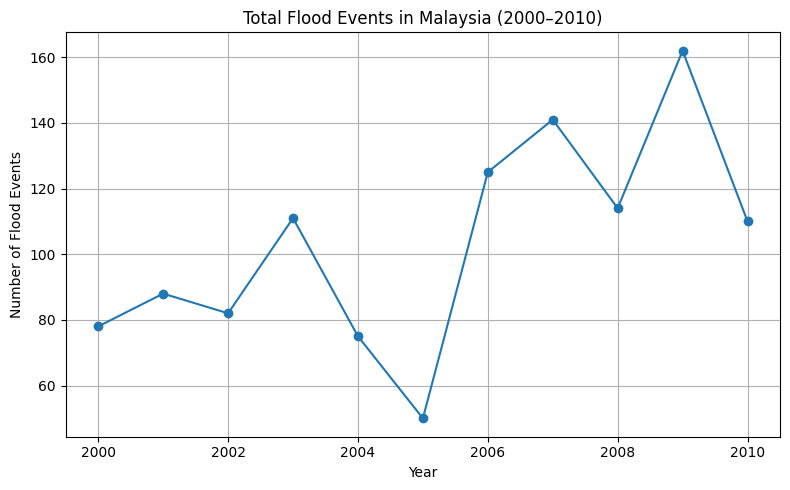

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(yearly.index, yearly.values, marker='o')
plt.title("Total Flood Events in Malaysia (2000–2010)")
plt.xlabel("Year")
plt.ylabel("Number of Flood Events")
plt.grid(True)
plt.tight_layout()
plt.show()


Figure 2. Flood Hotspots Location 

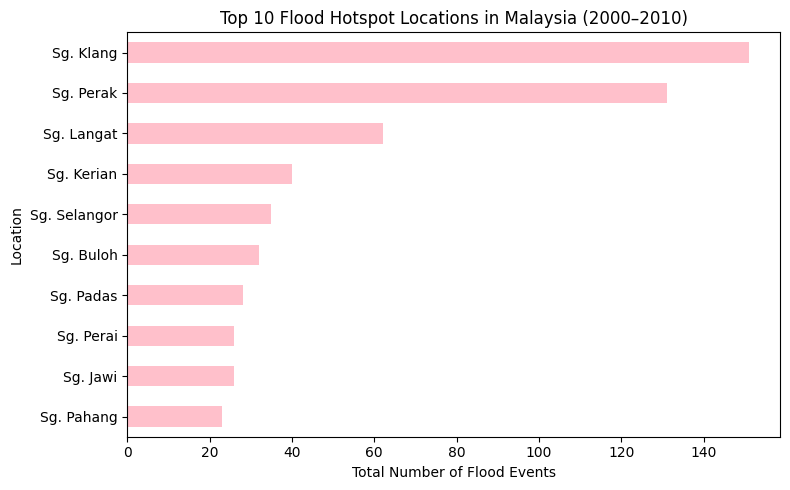

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
top10.sort_values().plot(
    kind="barh",
    color="pink")
plt.title("Top 10 Flood Hotspot Locations in Malaysia (2000–2010)")
plt.xlabel("Total Number of Flood Events")
plt.ylabel("Location")
plt.tight_layout()
plt.show()


Figure 3. Seasonal patterns of flooding

#Results

The bar chart shows that flood occurrences varies from year to year.
Certain years record noticeably higher flood events, reinforcing the observation
that flooding in Malaysia is episodic rather than constant over time.

#Limitation
Data doesnt show monthly, raw data showed annual flood data segregation


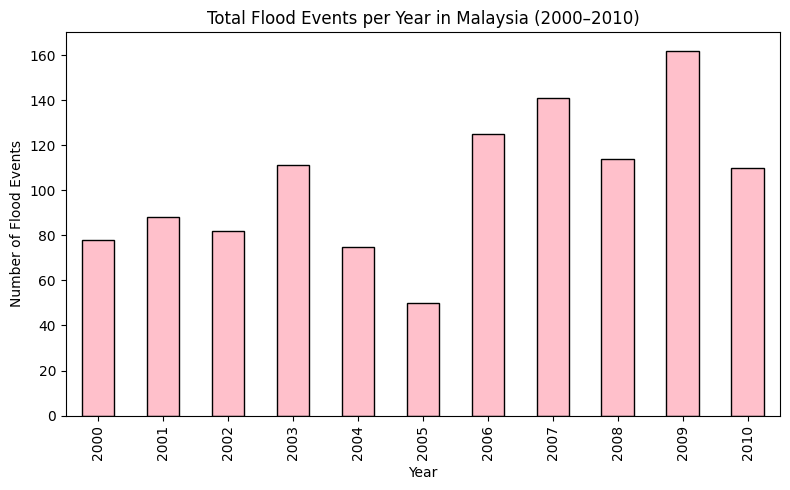

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
yearly.plot(
    kind="bar",
    color="pink",
    edgecolor="black")
plt.title("Total Flood Events per Year in Malaysia (2000–2010)")
plt.xlabel("Year")
plt.ylabel("Number of Flood Events")
plt.tight_layout()
plt.show()
